# 🔍 Exploratory Data Analysis — Credit Card Fraud Detection
**Dataset**: [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Features**: 30 input features (Time, Amount, V1–V28) + 1 binary target (`Class`)  
**Goal**: Understand distributions, class imbalance, correlations, and anomalies before modelling.


## About the Dataset

This dataset contains **credit card transactions made by European cardholders in September 2013** and is widely used for fraud detection research and machine learning classification tasks.

### Key Statistics

| Metric | Value |
|----------|----------|
| Total Transactions | 284,807 |
| Fraudulent Transactions | 492 |
| Legitimate Transactions | 284,315 |
| Fraud Rate | 0.172% |
| Observation Period | 2 Days |

### Features

The dataset contains **31 columns**:

- **Time** – Seconds elapsed between each transaction and the first transaction in the dataset.
- **Amount** – Transaction amount.
- **V1 – V28** – Anonymized numerical features obtained through **Principal Component Analysis (PCA)**.
- **Class** – Target variable:
  - `0` = Legitimate transaction
  - `1` = Fraudulent transaction

### Data Privacy

Due to confidentiality and privacy requirements, the original transaction attributes are not available. Most features have been transformed using PCA, making them anonymous while preserving useful patterns for fraud detection.

### Class Imbalance

A major challenge of this dataset is its **extreme class imbalance**:

- Legitimate transactions: **99.828%**
- Fraudulent transactions: **0.172%**
- Approximately **1 fraud transaction per 577 legitimate transactions**

This imbalance makes fraud detection particularly difficult because standard machine learning models may become biased toward predicting the majority class.

### Evaluation Considerations

Because of the severe imbalance, **accuracy is not a reliable performance metric**. A model predicting every transaction as legitimate would achieve over **99.8% accuracy** while failing to detect any fraud.

More suitable evaluation metrics include:

- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC (Area Under the Precision-Recall Curve)

Among these, **PR-AUC** is often preferred because it focuses on the model's ability to identify the rare fraud class.

### Objective

The goal is to build a machine learning model capable of accurately identifying fraudulent transactions while minimizing false positives and false negatives in a highly imbalanced environment.

## 1. Setup & Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "#0f1117",
    "axes.facecolor": "#1a1d2e",
    "axes.edgecolor": "#3a3d5c",
    "axes.labelcolor": "#e0e0e0",
    "axes.titlecolor": "#ffffff",
    "xtick.color": "#aaaaaa",
    "ytick.color": "#aaaaaa",
    "grid.color": "#2a2d4a",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "text.color": "#e0e0e0",
    "legend.facecolor": "#1a1d2e",
    "legend.edgecolor": "#3a3d5c",
    "font.family": "DejaVu Sans",
})

FRAUD_COLOR   = "#ff4d6d"
NORMAL_COLOR  = "#4cc9f0"
ACCENT_COLOR  = "#f8961e"
PURPLE_COLOR  = "#9d4edd"

print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Load Data

In [3]:
df = pd.read_csv("../data/raw/creditcard.csv")
print(f"Shape : {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df.head()


Shape : (284807, 31)
Memory: 70.63 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 33 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   Time         284807 non-null  float64 
 1   V1           284807 non-null  float64 
 2   V2           284807 non-null  float64 
 3   V3           284807 non-null  float64 
 4   V4           284807 non-null  float64 
 5   V5           284807 non-null  float64 
 6   V6           284807 non-null  float64 
 7   V7           284807 non-null  float64 
 8   V8           284807 non-null  float64 
 9   V9           284807 non-null  float64 
 10  V10          284807 non-null  float64 
 11  V11          284807 non-null  float64 
 12  V12          284807 non-null  float64 
 13  V13          284807 non-null  float64 
 14  V14          284807 non-null  float64 
 15  V15          284807 non-null  float64 
 16  V16          284807 non-null  float64 
 17  V17          284807 non-null  float64 
 18  V18 

In [20]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727,14.046470
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527,5.835854
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000,10.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000,15.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000,19.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000,23.000000


## 3. Basic Overview

In [4]:
print("=" * 55)
print(f"  Rows       : {df.shape[0]:,}")
print(f"  Columns    : {df.shape[1]}")
print(f"  Duplicates : {df.duplicated().sum():,}")
print("=" * 55)
df.dtypes.value_counts().rename("count").to_frame()


  Rows       : 284,807
  Columns    : 31
  Duplicates : 1,081


,count
float64,30
int64,1


In [5]:
# Column types
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical columns  : {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")
print()
print("Numerical:", num_cols[:10], "... (truncated)")


Numerical columns  : 31
Categorical columns: 0

Numerical: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9'] ... (truncated)


## 4. Missing Values Analysis

## 5. Target Distribution — Class Imbalance

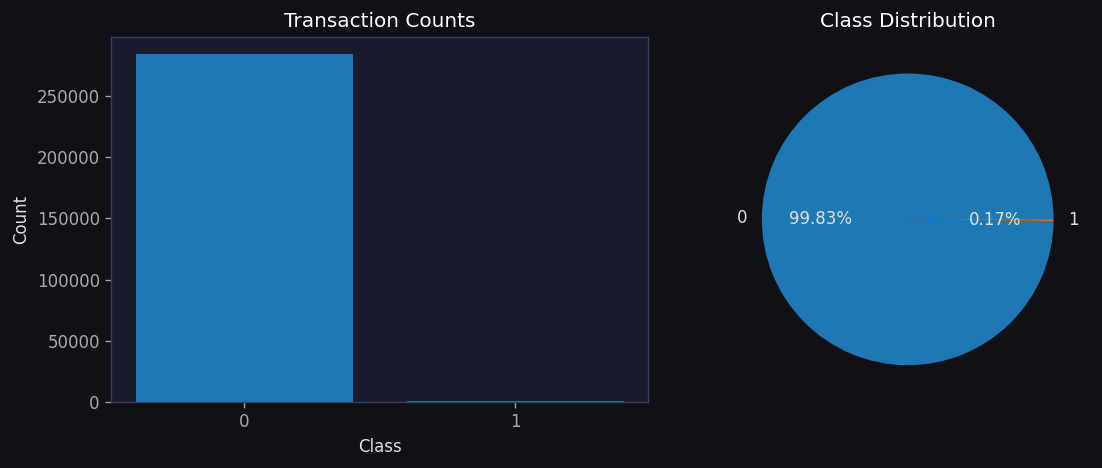

In [9]:
import matplotlib.pyplot as plt

counts = df["Class"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
ax[0].bar(counts.index.astype(str), counts.values)
ax[0].set_title("Transaction Counts")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

# Pie chart
ax[1].pie(
    counts.values,
    labels=counts.index.astype(str),
    autopct="%1.2f%%"
)
ax[1].set_title("Class Distribution")

plt.tight_layout()
plt.show()

In [21]:
# Simple — unique count per column
df.nunique()


Time           124592
V1             275663
V2             275663
V3             275663
V4             275663
V5             275663
V6             275663
V7             275663
V8             275663
V9             275663
V10            275663
V11            275663
V12            275663
V13            275663
V14            275663
V15            275663
V16            275663
V17            275663
V18            275663
V19            275663
V20            275663
V21            275663
V22            275663
V23            275663
V24            275663
V25            275663
V26            275663
V27            275663
V28            275663
Amount          32767
Class               2
Hour               24
Amount_Band         6
dtype: int64

## 6. Amount & Time Feature Analysis

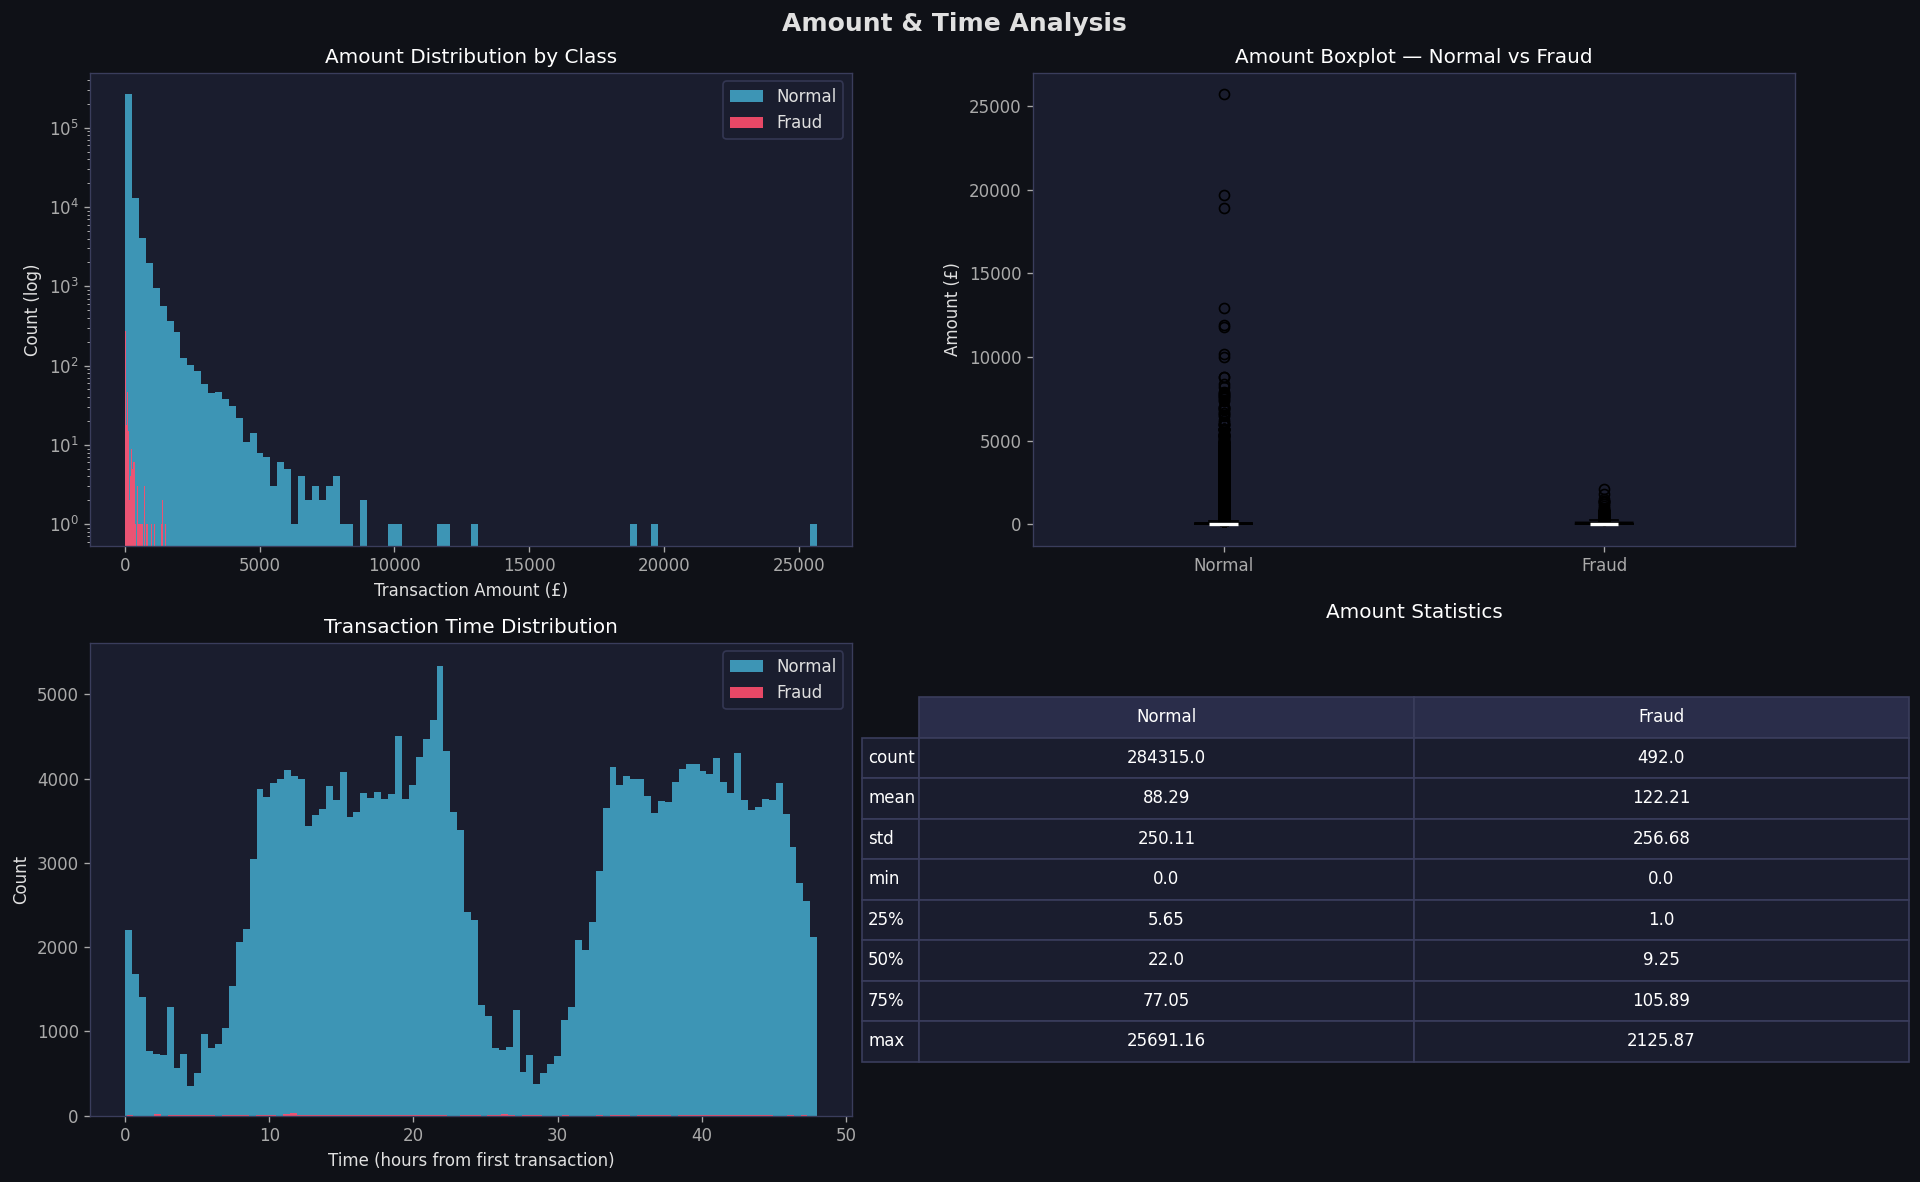

In [10]:
fraud  = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Amount distribution (log scale)
axes[0, 0].hist(normal["Amount"] + 0.01, bins=100,
                color=NORMAL_COLOR, alpha=0.7, label="Normal", log=True)
axes[0, 0].hist(fraud["Amount"] + 0.01, bins=100,
                color=FRAUD_COLOR, alpha=0.9, label="Fraud", log=True)
axes[0, 0].set_xlabel("Transaction Amount (£)")
axes[0, 0].set_ylabel("Count (log)")
axes[0, 0].set_title("Amount Distribution by Class")
axes[0, 0].legend()

# Amount boxplot
bp_data  = [normal["Amount"].values, fraud["Amount"].values]
bp = axes[0, 1].boxplot(bp_data, labels=["Normal", "Fraud"],
                        patch_artist=True, notch=True,
                        medianprops=dict(color="white", linewidth=2))
bp["boxes"][0].set_facecolor(NORMAL_COLOR)
bp["boxes"][1].set_facecolor(FRAUD_COLOR)
axes[0, 1].set_ylabel("Amount (£)")
axes[0, 1].set_title("Amount Boxplot — Normal vs Fraud")

# Time distribution
axes[1, 0].hist(normal["Time"] / 3600, bins=100,
                color=NORMAL_COLOR, alpha=0.7, label="Normal")
axes[1, 0].hist(fraud["Time"] / 3600, bins=100,
                color=FRAUD_COLOR, alpha=0.9, label="Fraud")
axes[1, 0].set_xlabel("Time (hours from first transaction)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Transaction Time Distribution")
axes[1, 0].legend()

# Amount statistics
stats_df = pd.DataFrame({
    "Normal" : normal["Amount"].describe(),
    "Fraud"  : fraud["Amount"].describe()
}).round(2)
axes[1, 1].axis("off")
tbl = axes[1, 1].table(cellText=stats_df.values,
                        rowLabels=stats_df.index,
                        colLabels=stats_df.columns,
                        loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor("#1a1d2e" if r > 0 else "#2a2d4a")
    cell.set_edgecolor("#3a3d5c")
    cell.set_text_props(color="white")
axes[1, 1].set_title("Amount Statistics", pad=15)

plt.suptitle("Amount & Time Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


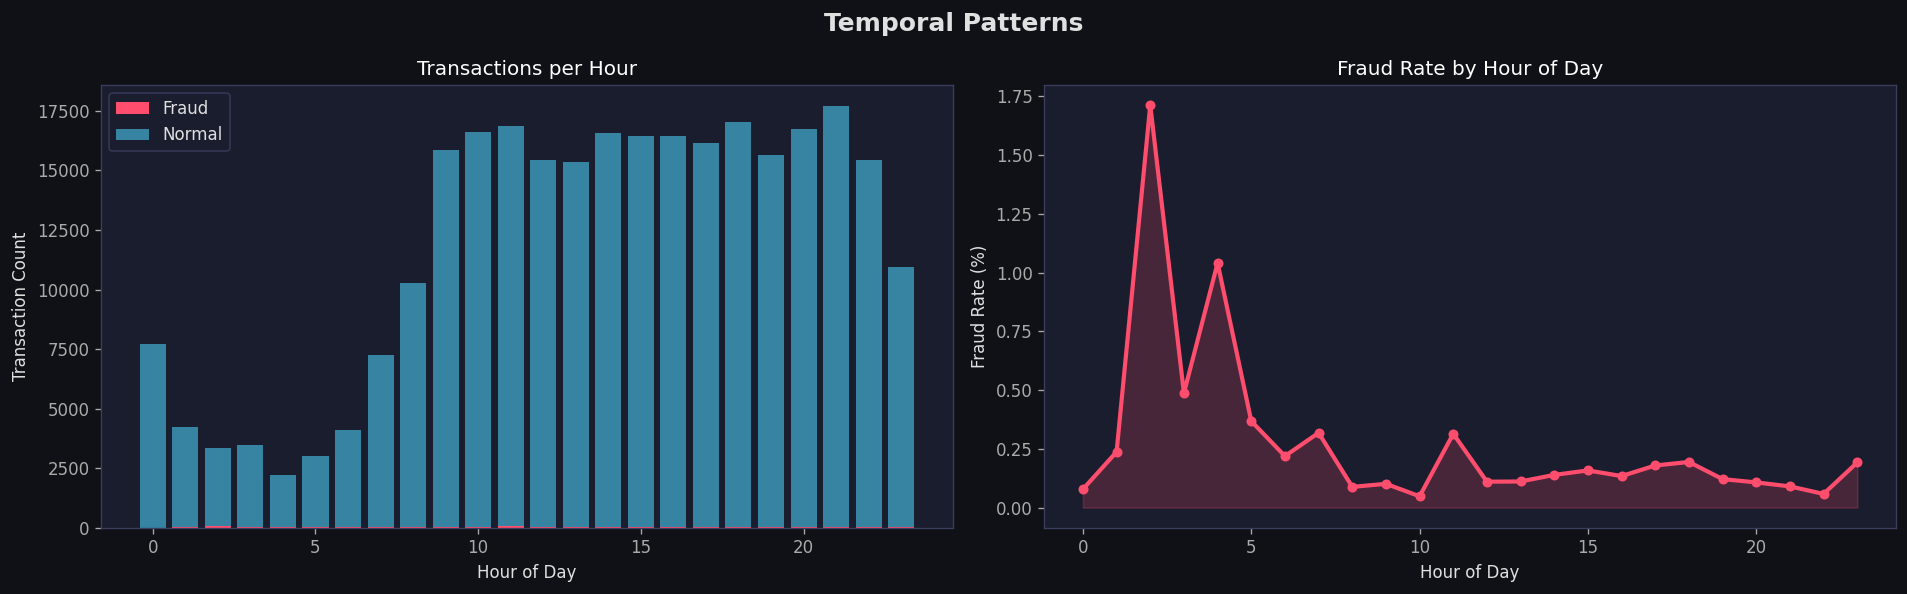

In [11]:
# Fraud by hour of day
df["Hour"] = (df["Time"] // 3600) % 24

hourly = df.groupby(["Hour", "Class"]).size().unstack(fill_value=0)
hourly.columns = ["Normal", "Fraud"]
hourly["Fraud_Rate_%"] = (hourly["Fraud"] / hourly.sum(axis=1) * 100).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(hourly.index, hourly["Fraud"], color=FRAUD_COLOR, label="Fraud")
axes[0].bar(hourly.index, hourly["Normal"], bottom=hourly["Fraud"],
            color=NORMAL_COLOR, alpha=0.6, label="Normal")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Transaction Count")
axes[0].set_title("Transactions per Hour")
axes[0].legend()

axes[1].plot(hourly.index, hourly["Fraud_Rate_%"],
             color=FRAUD_COLOR, linewidth=2.5, marker="o", markersize=5)
axes[1].fill_between(hourly.index, hourly["Fraud_Rate_%"],
                     alpha=0.2, color=FRAUD_COLOR)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_title("Fraud Rate by Hour of Day")

plt.suptitle("Temporal Patterns", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. PCA Feature Distributions (V1–V28)

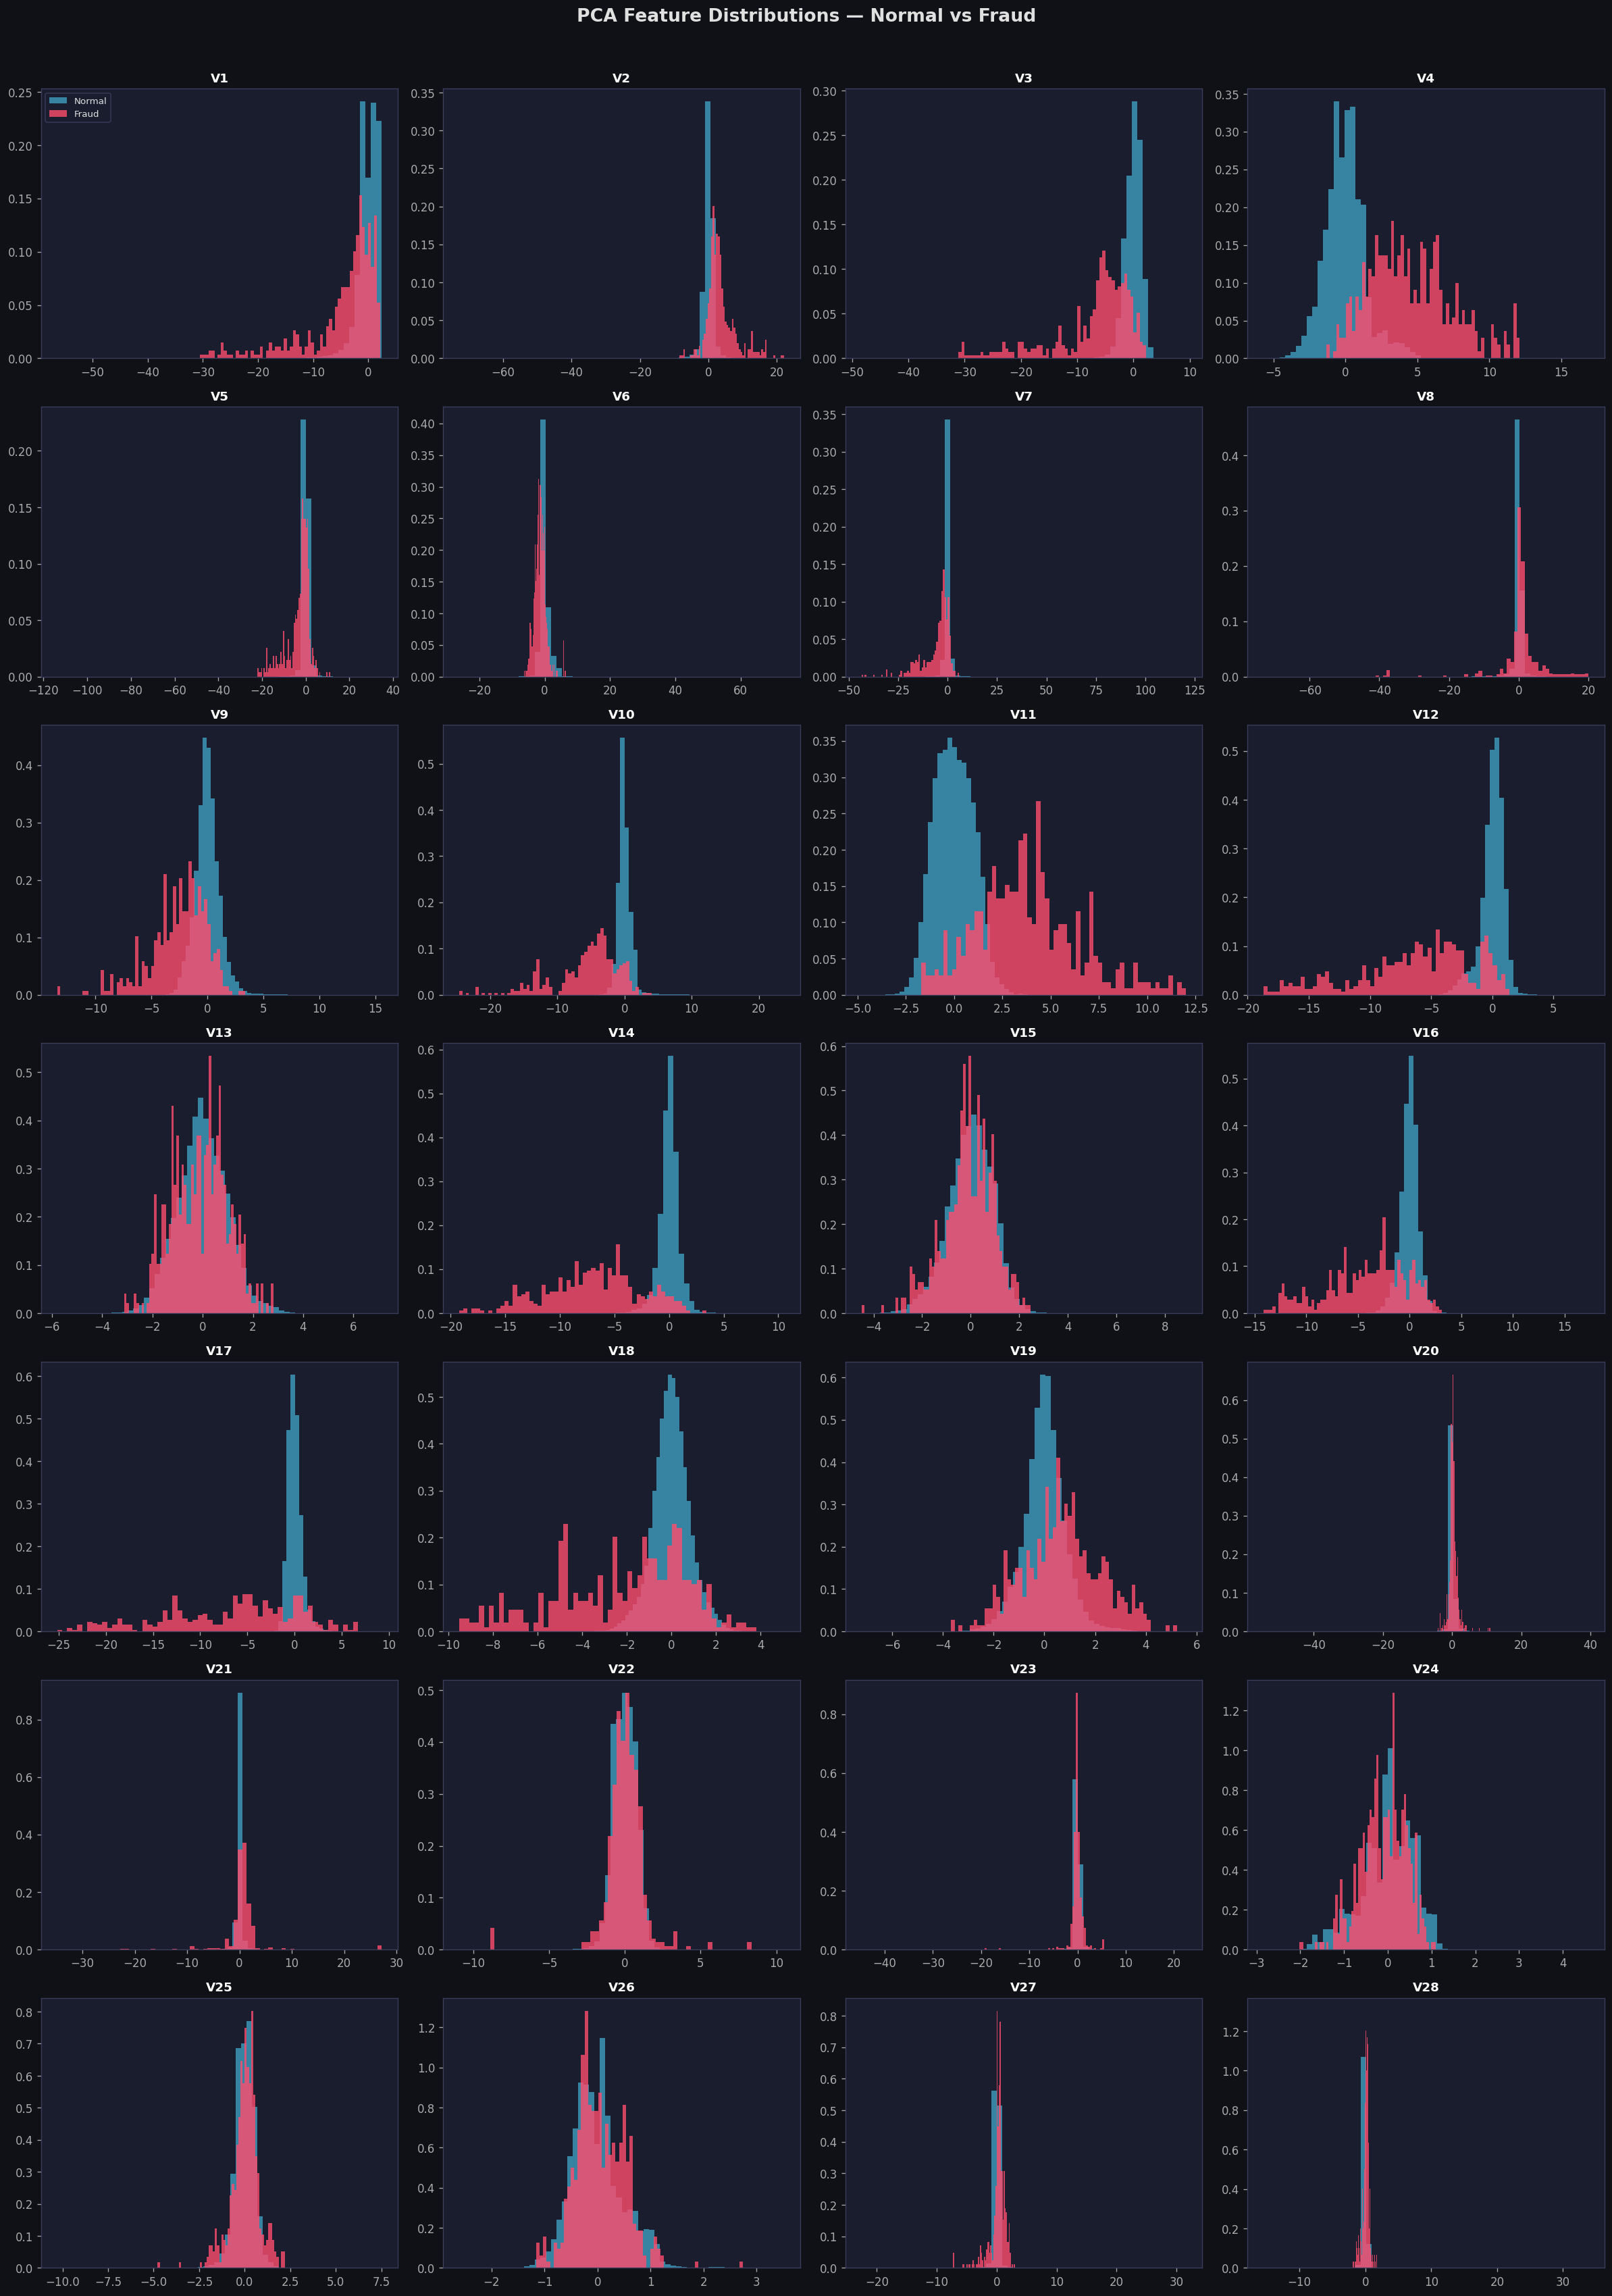

💡 Features where fraud distribution is VERY different from normal
   are the most discriminative for the model.


In [12]:
v_cols = [f"V{i}" for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    ax = axes[i]
    ax.hist(normal[col], bins=60, color=NORMAL_COLOR,
            alpha=0.6, density=True, label="Normal")
    ax.hist(fraud[col], bins=60, color=FRAUD_COLOR,
            alpha=0.8, density=True, label="Fraud")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("PCA Feature Distributions — Normal vs Fraud",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("💡 Features where fraud distribution is VERY different from normal")
print("   are the most discriminative for the model.")


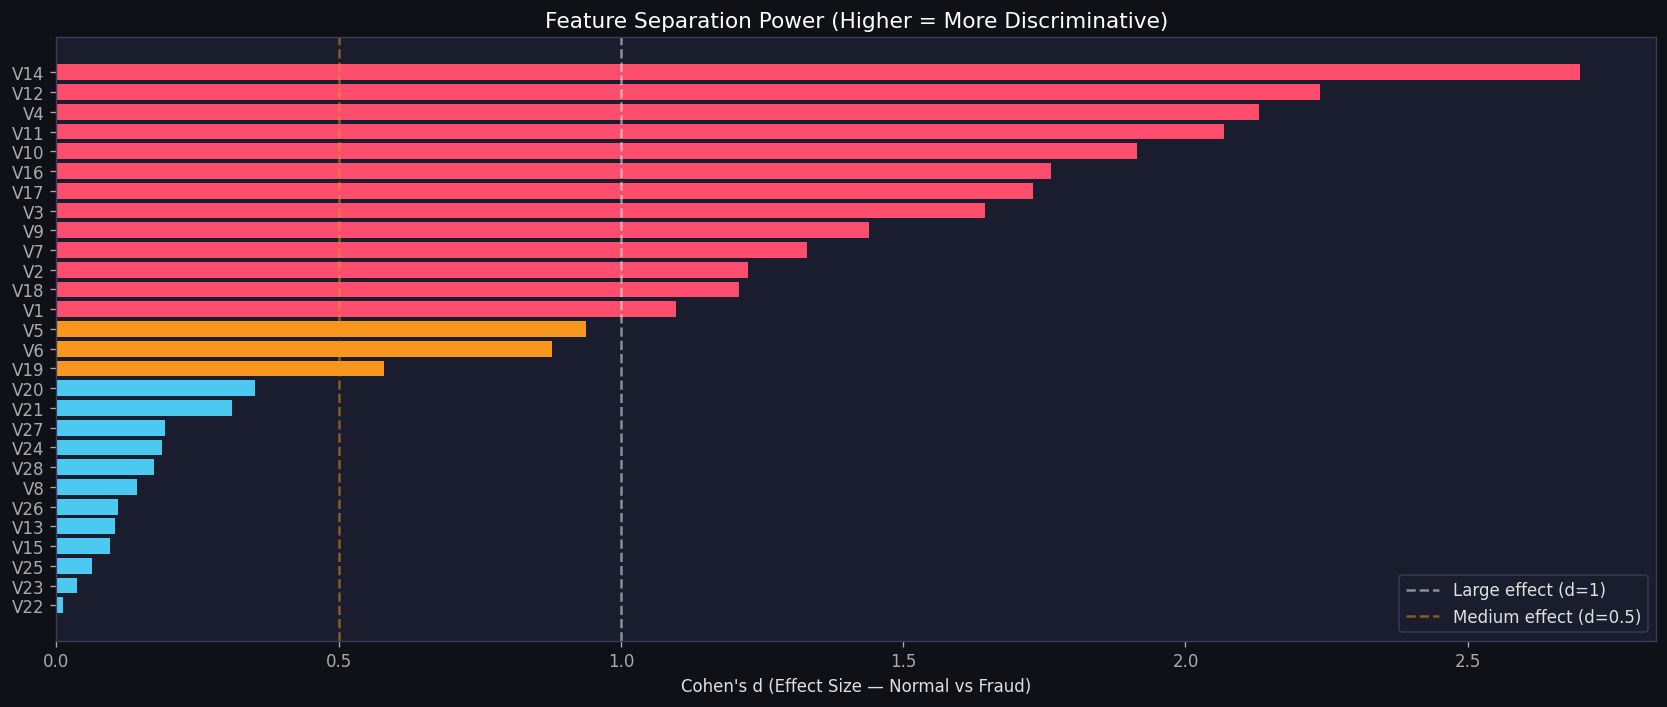

Top 10 most discriminative features:
Feature  Cohen_d
    V14 2.698555
    V12 2.239207
     V4 2.129773
    V11 2.067921
    V10 1.914218
    V16 1.761053
    V17 1.729872
     V3 1.644143
     V9 1.440333
     V7 1.330466


In [13]:
# Separation score per feature (KL divergence proxy using means)
separation = []
for col in v_cols:
    mean_diff   = abs(fraud[col].mean() - normal[col].mean())
    pooled_std  = (fraud[col].std() + normal[col].std()) / 2 + 1e-9
    cohen_d     = mean_diff / pooled_std
    separation.append({"Feature": col, "Cohen_d": cohen_d})

sep_df = pd.DataFrame(separation).sort_values("Cohen_d", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = [FRAUD_COLOR if v > 1.0 else ACCENT_COLOR if v > 0.5
          else NORMAL_COLOR for v in sep_df["Cohen_d"]]
bars = ax.barh(sep_df["Feature"], sep_df["Cohen_d"], color=colors)
ax.axvline(1.0, color="white", linestyle="--", alpha=0.5, label="Large effect (d=1)")
ax.axvline(0.5, color=ACCENT_COLOR, linestyle="--", alpha=0.5, label="Medium effect (d=0.5)")
ax.set_xlabel("Cohen's d (Effect Size — Normal vs Fraud)")
ax.set_title("Feature Separation Power (Higher = More Discriminative)", fontsize=13)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 most discriminative features:")
print(sep_df.head(10).to_string(index=False))


## 8. Correlation Analysis

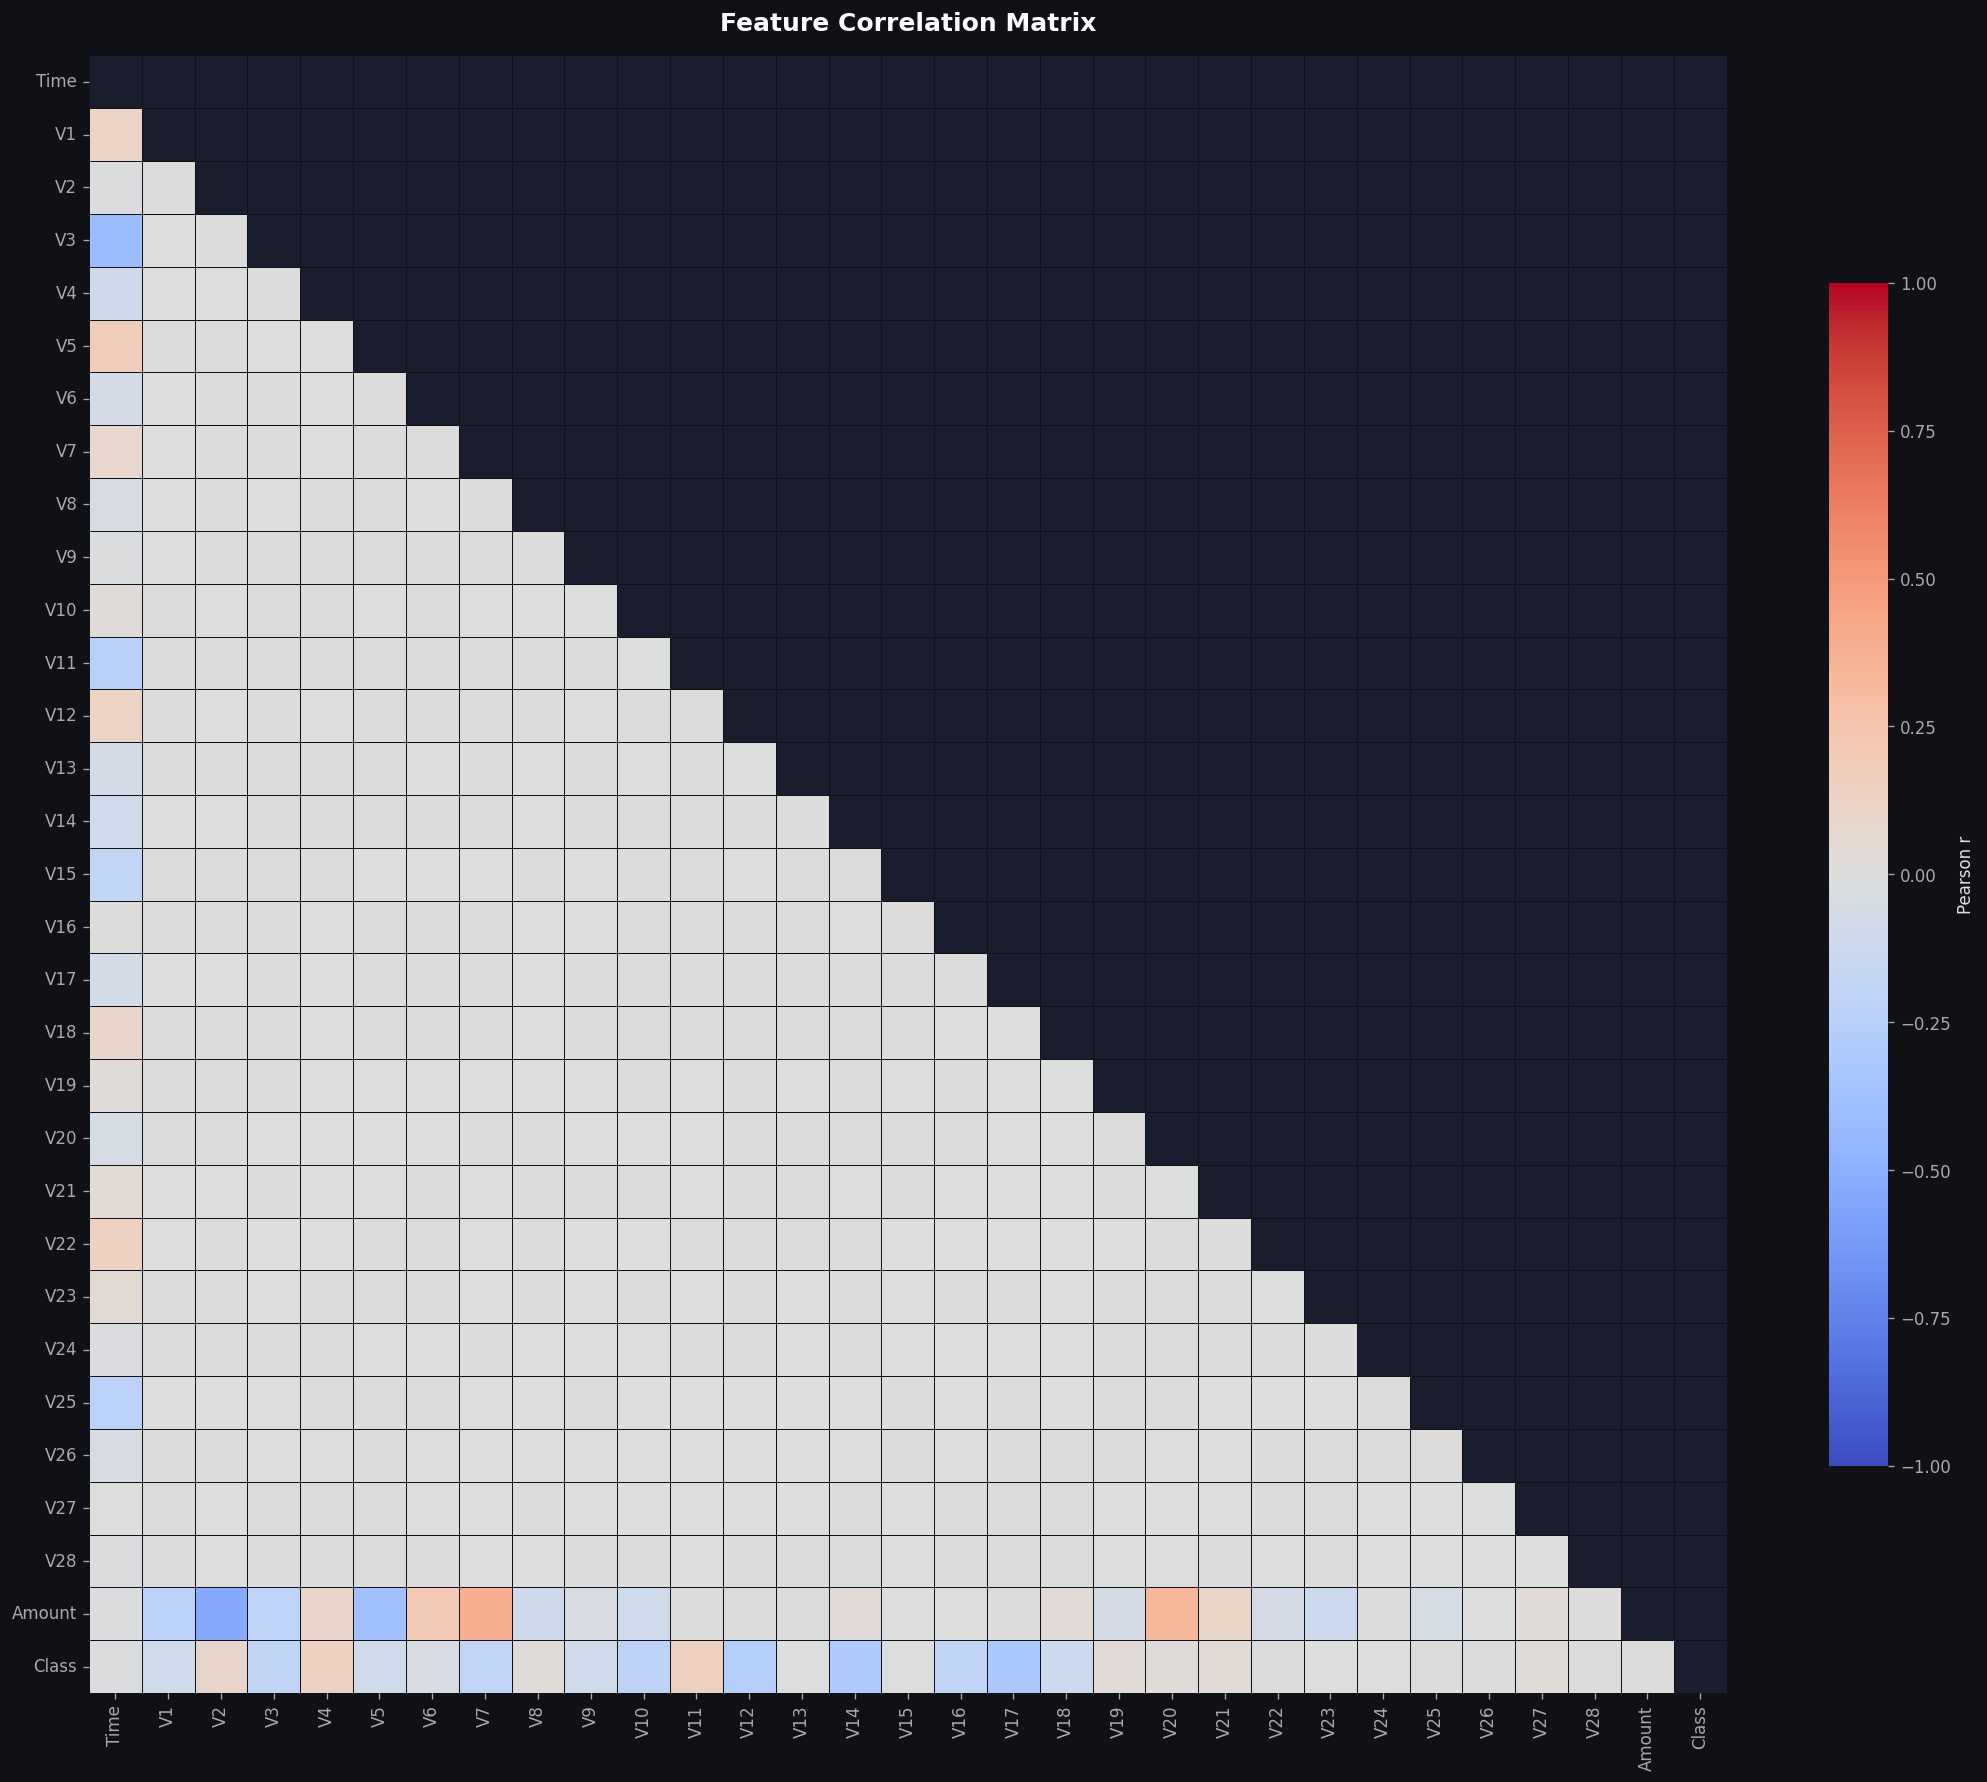

In [14]:
corr = df.drop(columns=["Hour"]).corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="#0f1117",
    annot=False, square=True,
    cbar_kws={"shrink": 0.7, "label": "Pearson r"}
)
ax.set_title("Feature Correlation Matrix", fontsize=15, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


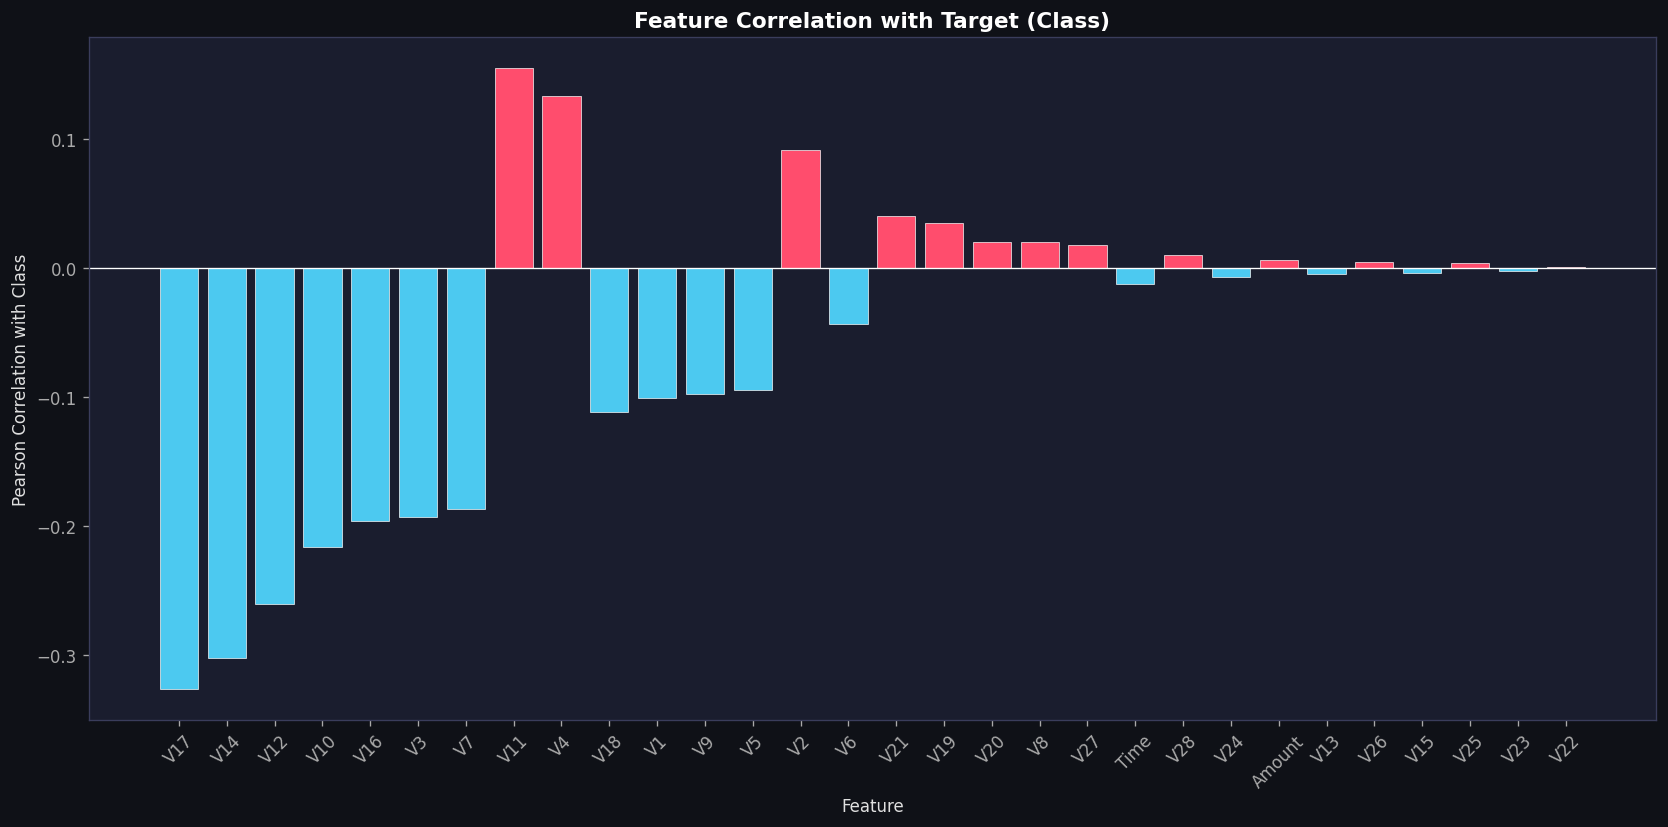

Top positively correlated with fraud:
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783

Top negatively correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539


In [15]:
# Correlation with target
target_corr = corr["Class"].drop("Class").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
colors = [FRAUD_COLOR if v > 0 else NORMAL_COLOR for v in target_corr.values]
ax.bar(target_corr.index, target_corr.values, color=colors, edgecolor="white", linewidth=0.4)
ax.axhline(0, color="white", linewidth=0.8)
ax.set_xlabel("Feature")
ax.set_ylabel("Pearson Correlation with Class")
ax.set_title("Feature Correlation with Target (Class)", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Top positively correlated with fraud:")
print(target_corr[target_corr > 0].head(5).to_string())
print("\nTop negatively correlated with fraud:")
print(target_corr[target_corr < 0].head(5).to_string())


## 9. Outlier Analysis

In [16]:
# Z-score outliers per class
z_scores = np.abs(stats.zscore(df[v_cols + ["Amount"]]))
outlier_mask = (z_scores > 3).any(axis=1)

print(f"Total outliers (|z| > 3 on any feature): {outlier_mask.sum():,}")
print(f"  → Normal transactions : {outlier_mask[df['Class']==0].sum():,}")
print(f"  → Fraud  transactions : {outlier_mask[df['Class']==1].sum():,}")
print(f"  → Outlier rate in fraud: "
      f"{outlier_mask[df['Class']==1].mean()*100:.1f}%")

# Amount outliers
q99 = df["Amount"].quantile(0.99)
q01 = df["Amount"].quantile(0.01)
print(f"\nAmount 1st percentile : £{q01:.2f}")
print(f"Amount 99th percentile: £{q99:.2f}")
print(f"Extreme high-value txns (>£{q99:.0f}): {(df['Amount'] > q99).sum():,}")


Total outliers (|z| > 3 on any feature): 37,816
  → Normal transactions : 37,372
  → Fraud  transactions : 444
  → Outlier rate in fraud: 90.2%

Amount 1st percentile : £0.12
Amount 99th percentile: £1017.97
Extreme high-value txns (>£1018): 2,849


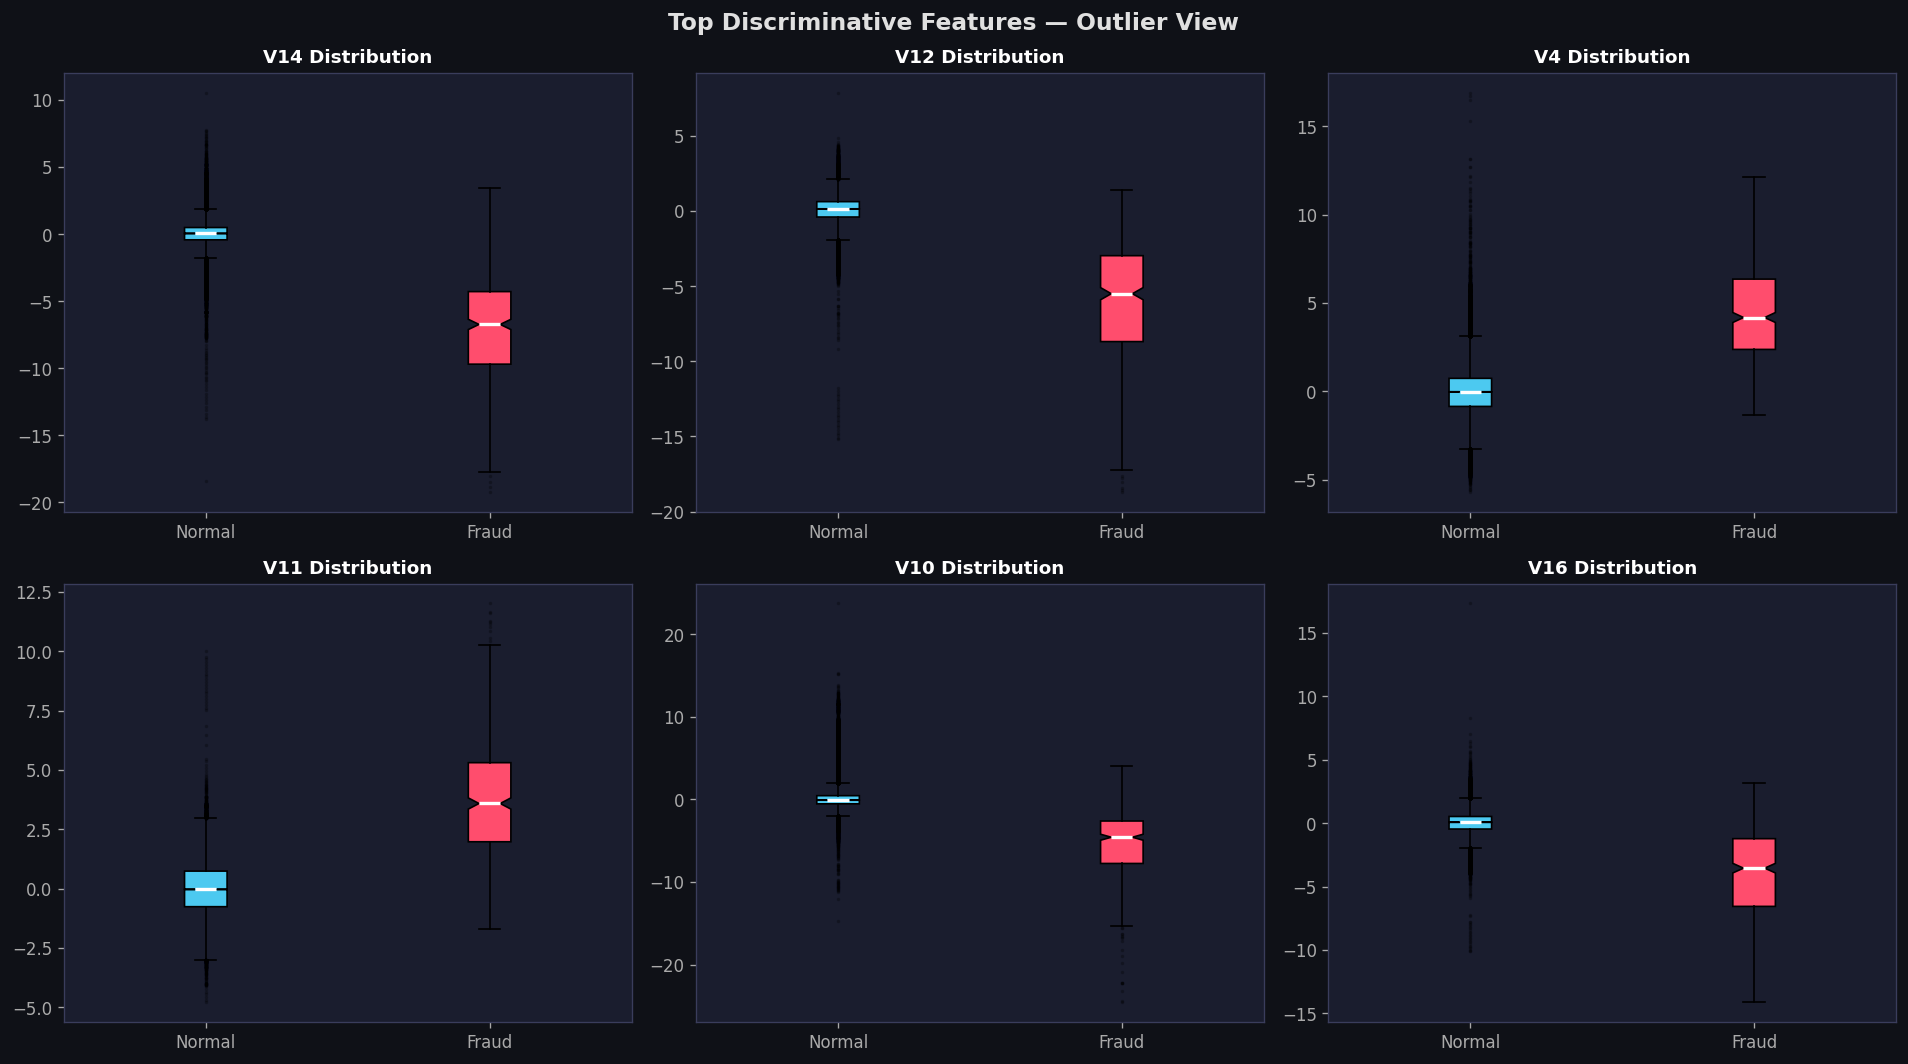

In [17]:
# Boxplots for top discriminative V features
top_feats = sep_df["Feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top_feats):
    ax = axes[i]
    bp = ax.boxplot(
        [normal[col].values, fraud[col].values],
        labels=["Normal", "Fraud"],
        patch_artist=True,
        notch=True,
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
        medianprops=dict(color="white", linewidth=2)
    )
    bp["boxes"][0].set_facecolor(NORMAL_COLOR)
    bp["boxes"][1].set_facecolor(FRAUD_COLOR)
    ax.set_title(f"{col} Distribution", fontsize=11, fontweight="bold")

plt.suptitle("Top Discriminative Features — Outlier View",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Fraud Pattern Deep Dive

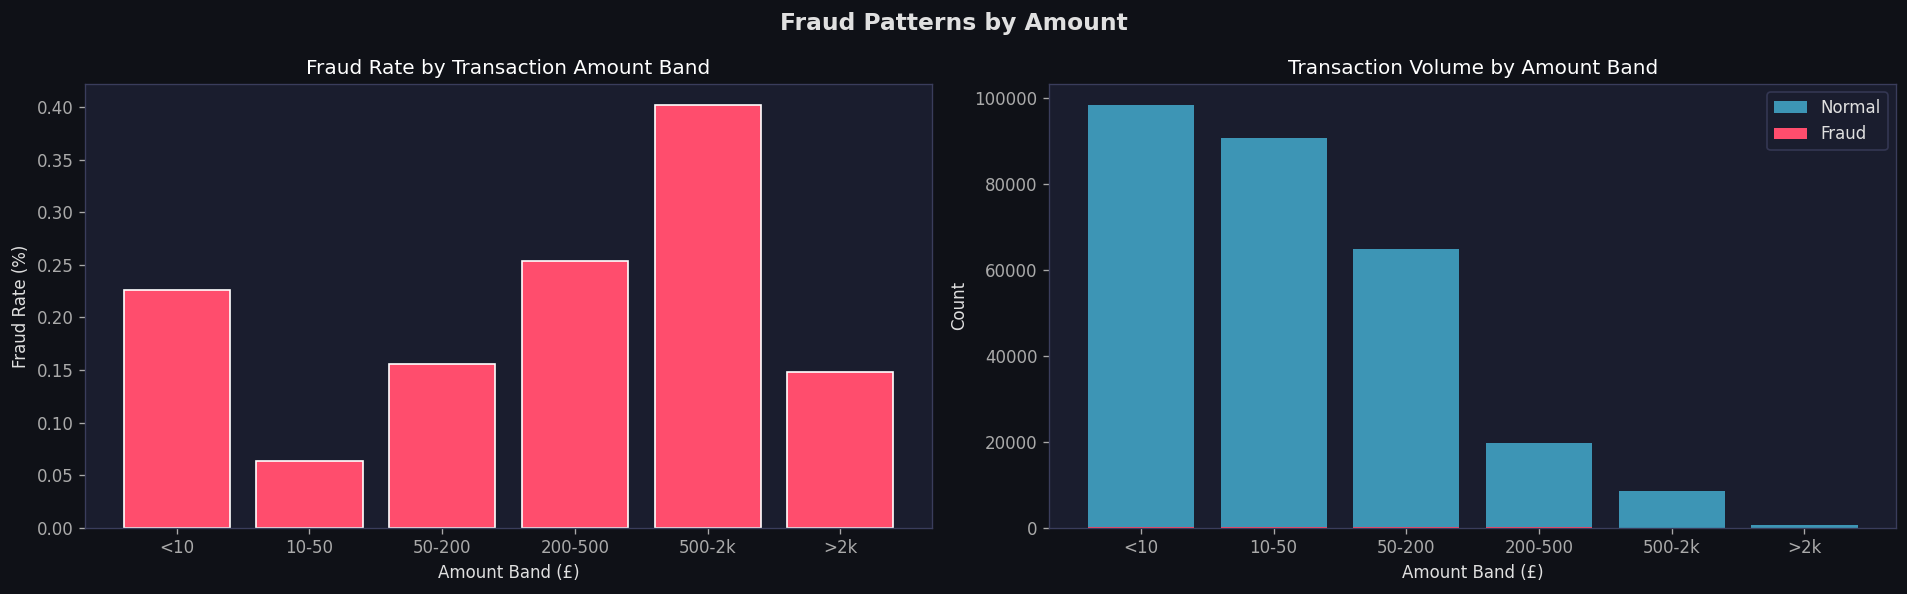

,Total,Fraud,Fraud_Rate_%
Amount_Band,,,
<10,98439,222,0.226
10-50,90781,57,0.063
50-200,64925,101,0.156
200-500,19695,50,0.254
500-2k,8466,34,0.402
>2k,676,1,0.148


In [18]:
# Amount bands
bins   = [0, 10, 50, 200, 500, 2000, df["Amount"].max() + 1]
labels = ["<10", "10-50", "50-200", "200-500", "500-2k", ">2k"]
df["Amount_Band"] = pd.cut(df["Amount"], bins=bins, labels=labels)

band_stats = df.groupby("Amount_Band", observed=True)["Class"].agg(
    Total="count",
    Fraud="sum"
)
band_stats["Fraud_Rate_%"] = (band_stats["Fraud"] / band_stats["Total"] * 100).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(band_stats.index.astype(str), band_stats["Fraud_Rate_%"],
            color=FRAUD_COLOR, edgecolor="white")
axes[0].set_xlabel("Amount Band (£)")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].set_title("Fraud Rate by Transaction Amount Band")

axes[1].bar(band_stats.index.astype(str), band_stats["Total"],
            color=NORMAL_COLOR, alpha=0.7, label="Normal")
axes[1].bar(band_stats.index.astype(str), band_stats["Fraud"],
            color=FRAUD_COLOR, label="Fraud")
axes[1].set_xlabel("Amount Band (£)")
axes[1].set_ylabel("Count")
axes[1].set_title("Transaction Volume by Amount Band")
axes[1].legend()

plt.suptitle("Fraud Patterns by Amount", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
display(band_stats)


##  Key EDA Findings And Notes

### Class Imbalance
- Only **~0.17%** of transactions are fraudulent — severe imbalance
- Must use **SMOTE**, **class weights**, or **threshold tuning** during modelling
- Evaluation metric should be **PR-AUC** or **F1**, NOT accuracy because the true positive is the most important here

### Missing Values
- **No missing values** in the creditcard.csv dataset 
- so imputation is not needed here
 
### Feature Types
- **V1–V28**: PCA-transformed numerical features (no raw card/personal data)
- **Amount**: Highly right-skewed → log transform has to use here
- **Time**: Seconds elapsed → converted to Hour-of-day cyclic feature
- **No categorical features** in this dataset

### Discriminative Features
- **V4, V11, V14, V17** show the largest separation between fraud and normal
- **V1, V3, V7, V10** also highly discriminative
- **Amount** alone is not a strong fraud indicator

### Outliers
- Outlier rate is higher in fraud transactions
- Fraud occurs across all amount ranges but has peaks in certain bands
- ensemble methods like xgboost/lightbgm handle outliers natively so no removal needed

### Temporal Patterns
- Fraud appears to spike at certain hours — cyclic time features will help the model

###  Modelling Notes
1. Use **`scale_pos_weight`** (XGBoost) or **`class_weight`** (LightGBM) to handle imbalance not SMOTE beaucuse of the fake detail. fraud system has to be precise 
2. add **Amount_log** and **Hour_sin/cos** features   
3. Optimise the **PR-AUC** not ROC-AUC because of severe imbalance(so best pr-auc curve model will be selected)
4. also use scaling beacuse some features have more spread  
5. if haave better result with all models used lets use stacking method for more improvement

